# 📊 Retail Store Sales Analysis

Este projeto tem como objetivo explorar e analisar dados de vendas no varejo, identificando padrões de comportamento, sazonalidade e oportunidades de negócio.

A base de dados foi obtida do Kaggle e passou por um processo completo de limpeza e preparação antes da análise.

## 🎯 Objetivos

- Entender o comportamento das vendas ao longo do tempo  
- Identificar produtos e categorias mais relevantes  
- Analisar padrões sazonais  
- Detectar possíveis oportunidades de crescimento  

## 📂 Sobre os Dados

A base contém informações sobre:

- Datas de venda  
- Produtos e categorias  
- Quantidade vendida  
- Receita gerada  

Esses dados permitem análises tanto temporais quanto comerciais.

## 🧭 Etapas do Projeto

1. Limpeza e tratamento dos dados  
2. Análise exploratória (EDA)  
3. Visualizações  
4. Insights e conclusões  

## 🧹 Etapa 1: Limpeza e Tratamento dos Dados

Nesta etapa foram realizados:

- Padronização de colunas  
- Tratamento de valores nulos  
- Correção de tipos de dados  
- Remoção de duplicatas  

Essas etapas garantem maior confiabilidade nas análises posteriores.

## 📦 Importação das Bibliotecas e Carregamento da Base de Dados

Nesta etapa importamos as principais bibliotecas utilizadas para manipulação, análise e visualização dos dados.

Os dados são carregados em um DataFrame para facilitar a manipulação e análise.

In [175]:
# Importação e leitura
import pandas as pd  # Manipulação de dados em DataFrames
import numpy as np   # Operações numéricas
import matplotlib.pyplot as plt  # Visualização de dados
import seaborn as sns  # Visualizações estatísticas mais avançadas

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df_raw = pd.read_csv('retail_store_sales.csv', sep=';')
df = df_raw.copy()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08/04/24
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23/07/23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05/10/22
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07/05/22
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02/10/22


## ℹ️ Estrutura dos Dados

Analisamos os tipos de dados e a presença de valores nulos e a formatação de nomes das coluans

In [176]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
dtypes: float64(3), str(7)
memory usage: 982.6 KB


In [177]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [178]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08/04/24
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23/07/23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05/10/22
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07/05/22
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02/10/22


## 🔄 Conversão de Tipos de Dados

Garantimos que cada coluna esteja no formato adequado para análise.

In [179]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

df.head()

/var/folders/t8/l_h_m0_s7vj273x2srnrwy_w0000gn/T/ipykernel_1259/2918404522.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-08-04
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-05-10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-07-05
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-02-10


## 🧹 Tratamento de Valores Nulos

Valores ausentes podem comprometer a análise, portanto serão tratados adequadamente.

In [180]:
df.isnull().sum()

transaction_id         0
customer_id            0
category               0
item                1213
price_per_unit       609
quantity             604
total_spent          604
payment_method         0
location               0
transaction_date       0
dtype: int64

## 🧹 Tratamento de Valores Ausentes (price_per_unit, quantity e total_spent)

As colunas **price_per_unit**, **quantity** e **total_spent** possuem uma relação matemática direta:

> **total_spent = price_per_unit × quantity**

Com base nessa relação, foi possível recuperar valores ausentes utilizando as informações disponíveis nas demais colunas.

---

### 🔁 Estratégia Aplicada

Foram criadas funções para imputar valores faltantes de forma condicional:

- Quando **price_per_unit** está ausente, ele é calculado como:
  - `total_spent / quantity`

- Quando **quantity** está ausente, ela é calculada como:
  - `total_spent / price_per_unit`

- Quando **total_spent** está ausente, ele é calculado como:
  - `quantity × price_per_unit`

Cada cálculo só é realizado quando as outras duas variáveis necessárias estão disponíveis, garantindo consistência nos dados.

---

### ⚙️ Lógica Técnica

Foi utilizada uma abordagem vetorizada com `np.where`, permitindo:

- Melhor performance (evitando loops)
- Aplicação condicional eficiente
- Código mais limpo e escalável

Além disso, máscaras booleanas foram usadas para garantir que apenas os registros válidos fossem atualizados.

---

### ⚠️ Tratamento Final

Após a imputação, ainda podem existir registros onde não foi possível calcular o **total_spent** (devido à ausência de múltiplas variáveis).

Esses registros foram removidos:

- Pois não permitem análise de vendas
- E poderiam comprometer a qualidade dos insights

---

### ✅ Resultado

- Redução significativa de valores ausentes  
- Preservação máxima dos dados úteis  
- Base mais consistente para análise exploratória e visualizações  


In [181]:
# Tratamento da coluna price_per_unit

def add_price_per_unit(df):
    mask = (
        df['price_per_unit'].isna() &
        df['quantity'].notna() &
        df['total_spent'].notna()
    )

    df['price_per_unit'] = np.where(
        mask,
        df['total_spent'] / df['quantity'],
        df['price_per_unit']
    )
    return df

# Tratamento da coluna quantity

def add_quantity(df):
    mask = (
        df['quantity'].isna() &
        df['price_per_unit'].notna() &
        df['total_spent'].notna()
    )

    df['quantity'] = np.where(
        mask,
        df['total_spent'] / df['price_per_unit'],
        df['quantity']
    )
    return df


# Tratamento da coluna total_spent

def add_total_spent(df):
    mask = (
        df['total_spent'].isna() &
        df['price_per_unit'].notna() &
        df['quantity'].notna()
    )

    df['total_spent'] = np.where(
        mask,
        df['quantity'] * df['price_per_unit'],
        df['total_spent']
    )
    return df

add_price_per_unit(df)
add_quantity(df)
add_total_spent(df)

# Retirando as linhas onde não foi possível encontrar o valor total da venda
df = df.dropna(subset=['total_spent'])

## 🧩 Tratamento de Valores Ausentes na Coluna `item`

A coluna **item** apresentava valores ausentes que poderiam comprometer análises por produto.

Para resolver esse problema, foi utilizada uma abordagem baseada em **relação indireta entre variáveis**, explorando padrões existentes nos dados.

---

### 🔍 Estratégia Aplicada

Observou-se que a combinação de:

- **category**
- **price_per_unit**

poderia, em alguns casos, identificar unicamente um produto.

A partir disso, foi construída uma lógica para:

1. Identificar combinações únicas de `(category, price_per_unit)` associadas a apenas um item  
2. Criar um mapeamento confiável dessas combinações  
3. Utilizar esse mapeamento para preencher valores ausentes na coluna `item`  

---

### ⚙️ Construção do Mapeamento

Inicialmente, foi criada uma tabela auxiliar contendo combinações únicas:

- Remoção de valores nulos  
- Remoção de duplicidades  

Em seguida:

- Foi realizado um agrupamento por `category` e `price_per_unit`
- Contabilizando quantos itens diferentes existem para cada combinação

Apenas combinações com **um único item associado** foram consideradas, garantindo:

- Maior precisão na imputação  
- Evitando atribuições incorretas  

---

### 🔁 Preenchimento dos Valores Ausentes

O preenchimento foi feito através de um `merge` entre o dataset original e o mapeamento criado:

- Quando um valor de `item` estava ausente:
  - Ele foi substituído pelo valor correspondente do mapeamento  
- Quando não havia correspondência:
  - O valor permaneceu nulo  

Essa abordagem garante que apenas inferências confiáveis sejam aplicadas.

---

### ⚠️ Tratamento Final

Após a tentativa de imputação, ainda podem existir registros sem identificação de produto.

Esses registros foram removidos:

- Pois não permitem análises por item  
- E podem gerar distorções nos resultados  

---

### ✅ Resultado

- Recuperação inteligente de valores ausentes  
- Preservação da integridade dos dados  
- Base mais robusta para análises por produto e categoria  

---

### 💡 Observação Analítica

Essa abordagem demonstra como variáveis auxiliares podem ser utilizadas para reconstruir informações ausentes, explorando relações implícitas no dataset — uma prática comum em projetos reais de dados.

In [182]:
# Encontrando o nome do item pela junção da category e price_per_unit

dim_product = (
    df[['item', 'category', 'price_per_unit']]
    .dropna()
    .drop_duplicates()
)

def build_unique_mapping(dim_product):
    counts = (
        dim_product
        .groupby(['category', 'price_per_unit'])['item']
        .nunique()
        .reset_index(name='n_items')
    )

    unique_keys = counts[counts['n_items'] == 1]

    mapping = dim_product.merge(
        unique_keys[['category', 'price_per_unit']],
        on=['category', 'price_per_unit'],
        how='inner'
    )

    return mapping[['category', 'price_per_unit', 'item']]


def fill_missing_items(df, mapping):
    df = df.copy()

    df = df.merge(
        mapping,
        on=['category', 'price_per_unit'],
        how='left',
        suffixes=('', '_mapped')
    )

    df['item'] = df['item'].fillna(df['item_mapped'])

    df = df.drop(columns=['item_mapped'])

    return df

mapping = build_unique_mapping(dim_product)
df = fill_missing_items(df, mapping)

# Retirando as linhas onde não foi possível encontrar o nome do item
df = df.dropna(subset=['item'])


In [183]:
# Disgnóstico final

df.isnull().sum()

transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
dtype: int64

In [184]:
total_linhas_raw = len(df_raw)
total_linhas_df = len(df)

print(f'Foi mantida {total_linhas_df} linhas de {total_linhas_raw} '
      f'({(1 - total_linhas_df/total_linhas_raw) * 100:.2f}% de perda)')

Foi mantida 11971 linhas de 12575 (4.80% de perda)


## ✅ Resultado Final do Tratamento de Valores Nulos

Após a aplicação das estratégias de imputação e limpeza, foi realizada uma etapa final de remoção dos registros que ainda apresentavam valores ausentes em campos críticos para a análise.

---

### 📊 Impacto no Dataset

- Total inicial de registros: **12.575**  
- Total final de registros: **11.971**  
- Registros removidos: **604**  
- Percentual de perda: **4,80%**

---

### ⚖️ Avaliação da Perda de Dados

A taxa de remoção de **4,80%** é considerada **baixa** e aceitável dentro do contexto de análise de dados, especialmente considerando que:

- Os registros removidos não possuíam informações essenciais mesmo após as tentativas de imputação  
- A manutenção desses dados poderia comprometer a qualidade das análises  
- A base final permanece representativa e consistente  

---

### 🎯 Justificativa da Abordagem

Optou-se por priorizar a **qualidade dos dados** em vez da quantidade, garantindo que:

- Todas as análises sejam baseadas em informações confiáveis  
- Não haja distorções causadas por valores incompletos ou inconsistentes  
- Os insights gerados tenham maior validade analítica  

---

### 🚀 Resultado Final

O dataset final encontra-se:

- Consistente  
- Sem valores nulos em variáveis críticas  
- Pronto para análise exploratória e geração de insights  

---

### 💡 Consideração Final

O processo de tratamento de dados buscou um equilíbrio entre **recuperação de informações** e **remoção criteriosa**, refletindo uma abordagem realista e alinhada às boas práticas de projetos de dados.

In [185]:
df.to_csv("retail_store_sales_cleaned.csv")

## 🔍 Etapa 2: Análise Exploratória

Nesta fase buscamos entender a distribuição dos dados e identificar padrões iniciais.

As principais perguntas exploradas foram:

- Como as vendas evoluem ao longo do tempo?
- Quais produtos mais vendem?
- Quais categorias geram mais receita?
- Existe sazonalidade?
- Ticket médio mudou ao longo do tempo?

In [186]:
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-08-04
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-05-10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-07-05
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-02-10


In [187]:
# Preparação de data
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month

# 📈 Vendas ao longo do tempo
sales_over_time = (
    df.groupby(['year', 'month'])['total_spent']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

# 🏆 Top produtos
top_products = (
    df.groupby('item')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 🏷️ Categorias mais relevantes
top_categories = (
    df.groupby('category')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 📅 Sazonalidade
seasonality = (
    df.groupby(['year', 'month'])['total_spent']
    .sum()
    .reset_index()
)

# 💰 Ticket médio por período
ticket_medio = (
    df.groupby(['year', 'month'])['total_spent']
    .mean()
    .reset_index()
)

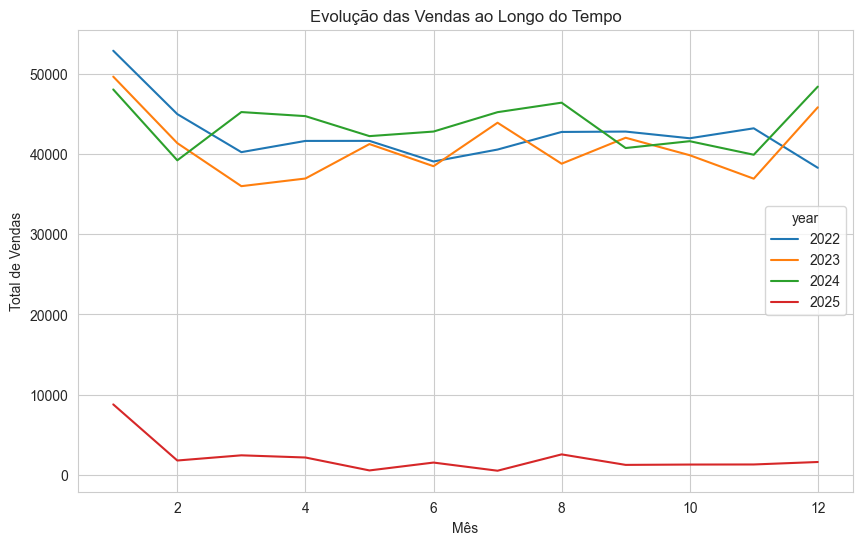

In [188]:
sales_over_time.pivot(index='month', columns='year', values='total_spent').plot()
plt.title('Evolução das Vendas ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('Total de Vendas')
plt.show()

## 📈 Evolução das Vendas ao Longo do Tempo

Observa-se que os anos de 2022, 2023 e 2024 apresentam padrões relativamente semelhantes de comportamento, com oscilações ao longo dos meses, mas sem variações abruptas.

O ano de 2024 demonstra desempenho consistentemente superior em diversos períodos, indicando possível crescimento do negócio ou melhoria nas estratégias comerciais.

Além disso, é possível identificar picos de vendas recorrentes em determinados meses (como início e final do ano), sugerindo um padrão sazonal.

Por outro lado, 2025 apresenta valores significativamente inferiores, o que pode indicar dados incompletos ou alteração drástica no desempenho da empresa, não sendo adequado para comparação direta entre os outros anos.

Como consequência, análises estratégicas devem considerar principalmente os anos completos (2022–2024), enquanto 2025 deve ser tratado com cautela.

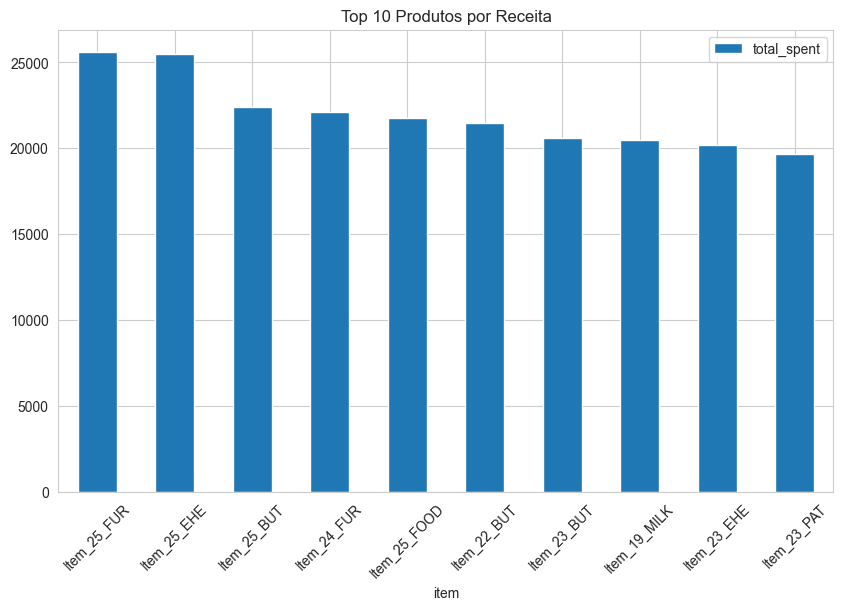

In [189]:
top_products.plot(kind='bar', x='item', y='total_spent')
plt.title('Top 10 Produtos por Receita')
plt.xticks(rotation=45)
plt.show()

## 🏆 Top 10 Produtos por Receita

Observa-se que há uma concentração relativamente equilibrada entre os produtos mais vendidos, sem um único item dominando de forma extrema a receita total.

Os dois produtos líderes apresentam desempenho muito próximo, indicando competição equilibrada entre itens de maior relevância.

Essa distribuição sugere que o negócio não depende exclusivamente de um único produto, o que reduz riscos operacionais.

Por outro lado, a proximidade entre os valores indica que pequenas mudanças de estratégia (como preço ou promoção) podem alterar significativamente o ranking.

Como consequência, ações comerciais direcionadas aos produtos do topo podem gerar ganhos relevantes de receita com baixo esforço.

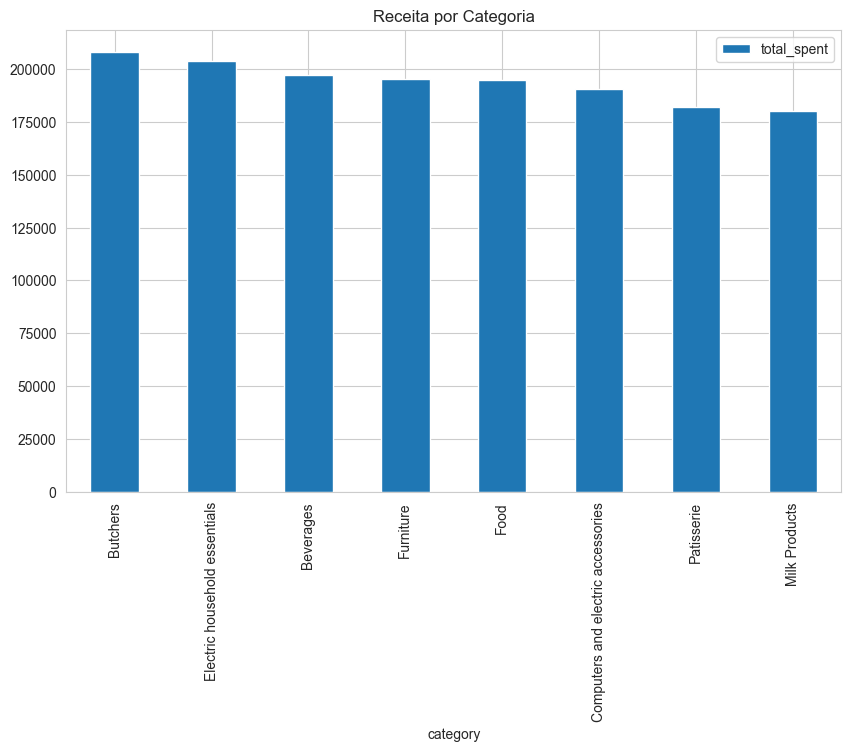

In [190]:
top_categories.plot(kind='bar', x='category', y='total_spent')
plt.title('Receita por Categoria')
plt.show()

## 🏷️ Receita por Categoria

Observa-se que a categoria "Butchers" apresenta a maior geração de receita, seguida de perto por "Electric household essentials" e "Beverages".

A diferença entre as categorias não é extremamente acentuada, indicando uma distribuição relativamente equilibrada da receita entre os segmentos.

Isso sugere que o negócio possui um portfólio diversificado, reduzindo dependência de uma única categoria.

No entanto, categorias como "Milk Products" e "Patisserie" apresentam menor participação, podendo indicar menor demanda ou menor estratégia comercial.

Como consequência, o negócio pode explorar duas frentes:
- Reforçar categorias líderes para maximizar receita
- Investigar categorias de menor desempenho para identificar oportunidades de crescimento

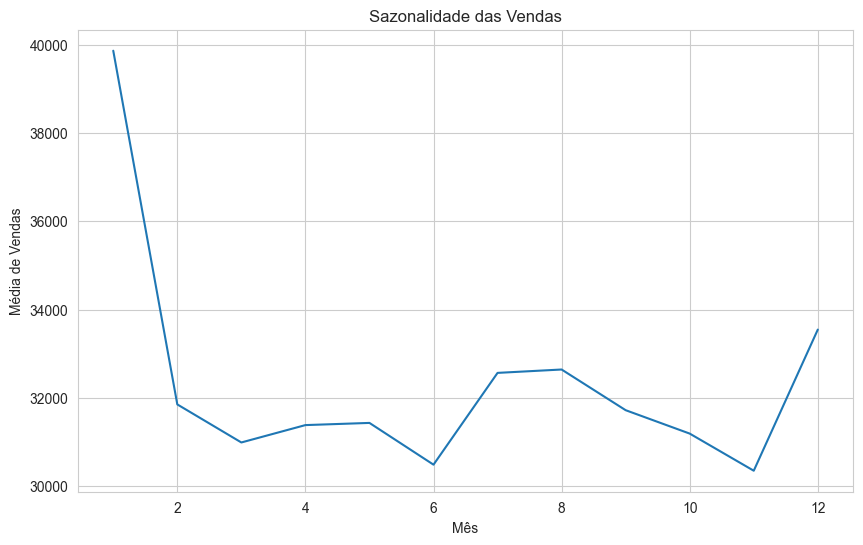

In [191]:
seasonality.groupby('month')['total_spent'].mean().plot()
plt.title('Sazonalidade das Vendas')
plt.xlabel('Mês')
plt.ylabel('Média de Vendas')
plt.show()

## 📅 Sazonalidade das Vendas

Observa-se que o mês 1 apresenta o maior volume médio de vendas, destacando-se significativamente em relação aos demais períodos.

Após esse pico inicial, há uma queda acentuada no mês 2, seguida por um comportamento relativamente estável ao longo do restante do ano, com pequenas oscilações.

Os meses 7 e 8 apresentam leve recuperação nas vendas, enquanto o mês 11 registra um dos menores desempenhos, seguido de nova alta no mês 12.

Esse padrão sugere a presença de sazonalidade, possivelmente associada a fatores como início de ano (reposição de estoque ou maior consumo) e aumento de demanda no final do ano.

Como consequência, o negócio pode otimizar suas estratégias:
- Reforçando estoque e campanhas nos meses de pico (1 e 12)
- Criando ações promocionais nos períodos de baixa (especialmente mês 11)

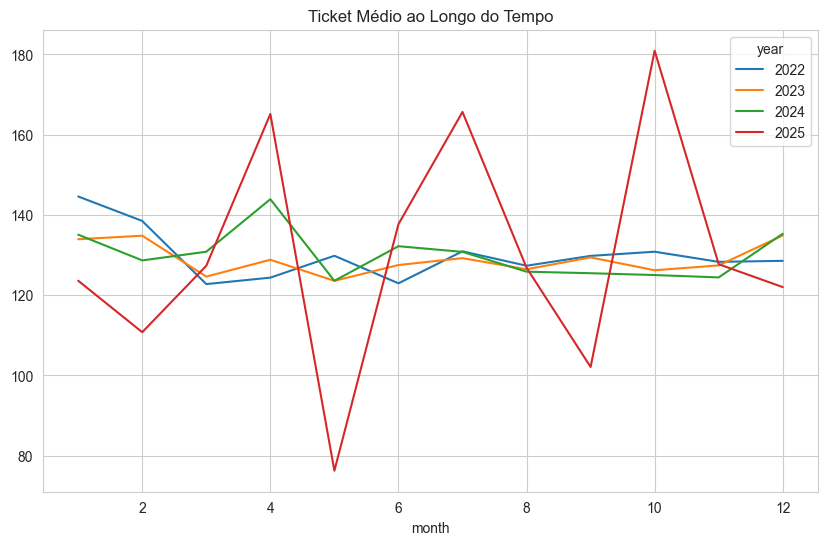

In [192]:
ticket_medio.pivot(index='month', columns='year', values='total_spent').plot()
plt.title('Ticket Médio ao Longo do Tempo')
plt.show()

## 💰 Ticket Médio ao Longo do Tempo

Observa-se que os anos de 2022, 2023 e 2024 apresentam comportamento relativamente estável no ticket médio ao longo dos meses, com pequenas variações.

Isso indica consistência no valor médio das transações, sugerindo estabilidade no perfil de consumo dos clientes.

Por outro lado, o ano de 2025 apresenta alta volatilidade, com variações abruptas entre os meses.

Esse comportamento pode indicar:
- Base de dados incompleta  
- Baixo volume de transações  
- Ou instabilidade recente no padrão de vendas  

Além disso, picos elevados (como no mês 10) podem indicar eventos pontuais, como compras de maior valor ou outliers.

Como consequência:
- Os anos de 2022–2024 são mais confiáveis para análise de tendência  
- O ano de 2025 deve ser analisado com cautela  
- Investigações adicionais podem ser feitas para entender os picos e quedas abruptas  

Esse indicador é essencial para avaliar não apenas o volume de vendas, mas também a qualidade da receita gerada.

## 🔀 Análises Cruzadas

Após a análise inicial, avançamos para investigações mais específicas, com o objetivo de entender o comportamento dos dados sob diferentes perspectivas.

---

## 🏷️ Análise 1 — Categorias com maior valor por venda

Nesta etapa, avaliamos quais categorias apresentam maior **ticket médio por transação**.  
O objetivo é entender se determinadas categorias vendem com maior valor agregado, mesmo que não sejam necessariamente as mais frequentes.

---

## 📦 Análise 2 — Produtos vendem muito ou vendem caro?

Aqui investigamos a relação entre **volume vendido** e **receita gerada por produto**.  
Essa análise ajuda a separar produtos com alto giro daqueles que se destacam por preço ou valor total vendido.

---

## 📈 Análise 3 — Categorias com crescimento ao longo do tempo

Nesta análise, observamos a evolução da receita por categoria ao longo dos anos.  
O objetivo é identificar quais categorias apresentam tendência de crescimento mais consistente.

---

## 📅 Análise 4 — Sazonalidade por categoria

Nem todas as categorias seguem o mesmo comportamento ao longo dos meses.  
Aqui analisamos se existe um padrão sazonal específico para cada categoria.

---

## 💰 Análise 5 — Evolução do ticket médio por categoria

Além da receita total, é importante avaliar se o **valor médio por venda** está aumentando ou diminuindo em cada categoria ao longo do tempo.

---

## 💳 Análise 6 — Receita e comportamento por método de pagamento

Nesta etapa, analisamos como os diferentes **métodos de pagamento** impactam a receita e o comportamento de compra.  
O objetivo é identificar quais métodos concentram maior volume financeiro e se estão associados a transações de maior valor.

---

## 💳 Análise 7 — Ticket médio por método de pagamento

Aqui avaliamos se existe variação no **valor médio das compras** de acordo com o método de pagamento utilizado.  
Essa análise ajuda a entender se determinados meios estão associados a compras maiores ou mais planejadas.

---

## 🌍 Análise 8 — Receita por localização

Nesta análise, investigamos quais regiões apresentam maior geração de receita.  
O objetivo é identificar áreas com maior potencial de mercado e relevância para o negócio.

---

## 🌍 Análise 9 — Ticket médio por localização

Por fim, avaliamos se o **valor médio por venda** varia entre diferentes localidades.  
O objetivo é entender se determinadas regiões apresentam maior poder de compra ou preferência por produtos de maior valor agregado.

In [193]:
# 🏷️ Análise 1 — Categorias com maior valor por venda
ticket_category = (
    df.groupby('category', as_index=False)['total_spent']
    .mean()
    .rename(columns={'total_spent': 'avg_ticket'})
    .sort_values('avg_ticket', ascending=False)
)

# 📦 Análise 2 — Produtos vendem muito ou vendem caro?
produto_analise = (
    df.groupby('item', as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_revenue=('total_spent', 'sum')
    )
)

produto_analise['avg_price_per_unit'] = (
    produto_analise['total_revenue'] / produto_analise['total_quantity']
)

produto_analise = produto_analise.sort_values('total_revenue', ascending=False)

# 📈 Análise 3 — Quais categorias crescem ao longo do tempo?
categoria_tempo = (
    df.groupby(['year', 'category'], as_index=False)['total_spent']
    .sum()
    .rename(columns={'total_spent': 'total_revenue'})
    .sort_values(['category', 'year'])
)

# 📅 Análise 4 — Sazonalidade por categoria
sazonal_categoria = (
    df.groupby(['month', 'category'], as_index=False)['total_spent']
    .sum()
    .rename(columns={'total_spent': 'total_revenue'})
    .sort_values(['category', 'month'])
)

# 💰 Análise 5 — O ticket médio está mudando dentro das categorias?
ticket_categoria_tempo = (
    df.groupby(['year', 'category'], as_index=False)['total_spent']
    .mean()
    .rename(columns={'total_spent': 'avg_ticket'})
    .sort_values(['category', 'year'])
)

# 💳 Análise 6 — Receita e comportamento por método de pagamento
payment_revenue_year = (
    df.groupby(['year', 'payment_method'], as_index=False)['total_spent']
    .sum()
    .rename(columns={'total_spent': 'total_revenue'})
    .sort_values(['year', 'total_revenue'], ascending=[True, False])
)

# 💳 Análise 7 — Ticket médio por método de pagamento
payment_ticket_year = (
    df.groupby(['year', 'payment_method'], as_index=False)['total_spent']
    .mean()
    .rename(columns={'total_spent': 'avg_ticket'})
    .sort_values(['year', 'avg_ticket'], ascending=[True, False])
)

# 🌍 Análise 8 — Receita por localização
location_revenue_year = (
    df.groupby(['year', 'location'], as_index=False)['total_spent']
    .sum()
    .rename(columns={'total_spent': 'total_revenue'})
    .sort_values(['year', 'total_revenue'], ascending=[True, False])
)

# 🌍 Análise 9 — Ticket médio por localização
location_ticket_year = (
    df.groupby(['year', 'location'], as_index=False)['total_spent']
    .mean()
    .rename(columns={'total_spent': 'avg_ticket'})
    .sort_values(['year', 'avg_ticket'], ascending=[True, False])
)


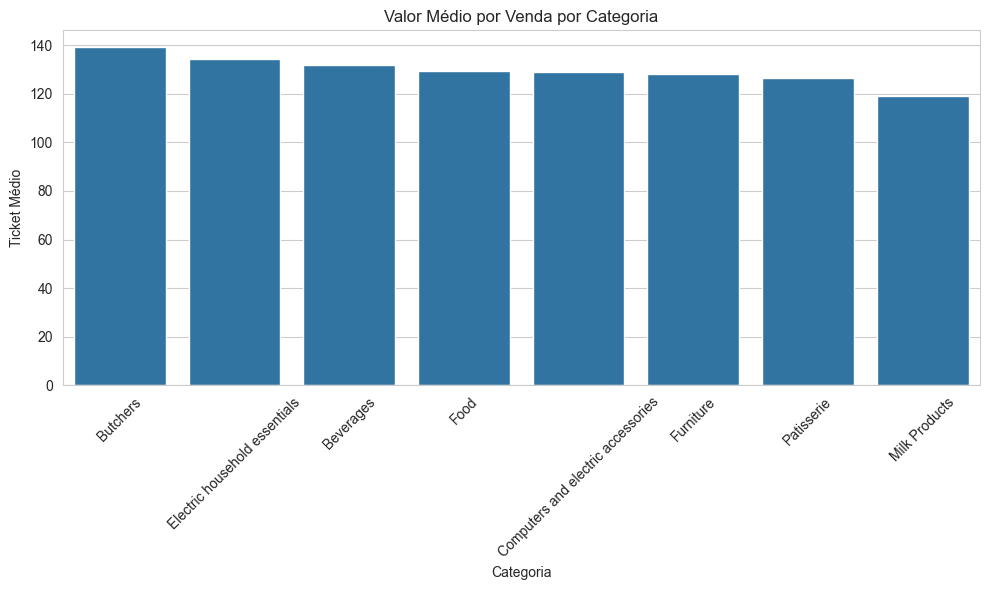

In [194]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ticket_category, x='category', y='avg_ticket')

plt.title('Valor Médio por Venda por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Ticket Médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🏷️ Valor Médio por Venda por Categoria (Revisado com Receita Total)

Observa-se que a categoria **Butchers** apresenta o maior ticket médio entre todas as categorias, além de também liderar em receita total.

Esse comportamento indica que essa categoria combina dois fatores altamente positivos:
- Alto valor por transação  
- Alto volume de vendas  

Isso a posiciona como um dos principais drivers de receita do negócio.

Além disso, categorias como **Electric household essentials** também apresentam forte desempenho em receita, mesmo com ticket médio ligeiramente inferior, sugerindo alto volume de vendas.

Por outro lado, categorias como **Milk Products** e **Patisserie** apresentam tanto menor ticket médio quanto menor receita total, indicando menor relevância no desempenho geral do negócio.

De forma geral, observa-se que:
- Categorias com maior ticket médio tendem também a apresentar maior receita  
- Não há grande distorção entre valor e volume, indicando consistência no padrão de consumo  

Como consequência, o negócio pode adotar estratégias distintas:

- Priorizar categorias como **Butchers** para maximização de receita  
- Trabalhar categorias intermediárias com foco em aumento de ticket médio ou volume  
- Avaliar categorias de menor desempenho para reposicionamento ou otimização  

Essa análise combinada (ticket médio + receita) fornece uma visão mais completa sobre o papel estratégico de cada categoria no negócio.

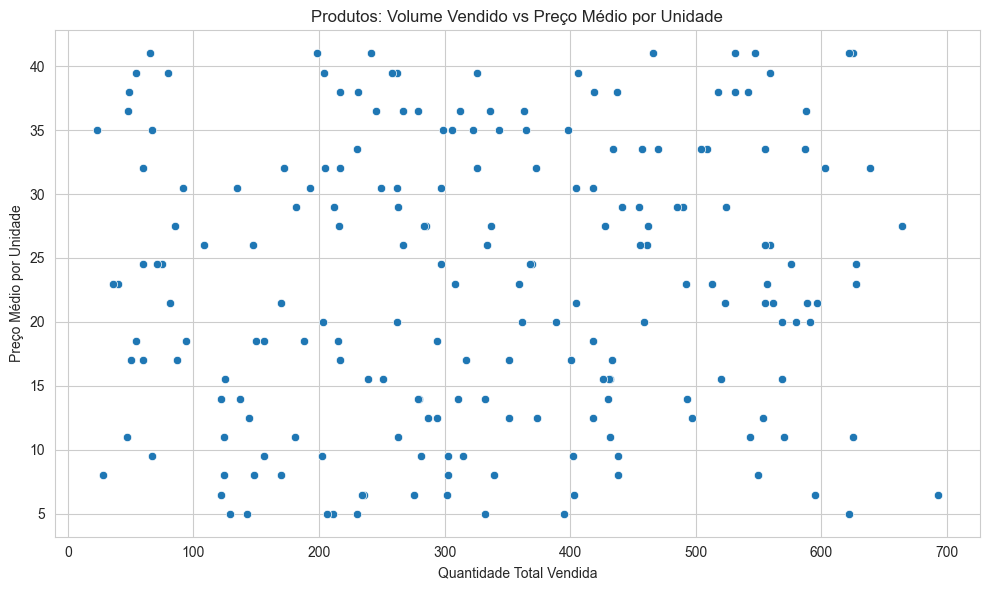

In [195]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=produto_analise,
    x='total_quantity',
    y='avg_price_per_unit'
)

plt.title('Produtos: Volume Vendido vs Preço Médio por Unidade')
plt.xlabel('Quantidade Total Vendida')
plt.ylabel('Preço Médio por Unidade')
plt.tight_layout()
plt.show()

## 📦 Relação entre Volume Vendido e Preço Médio por Produto

A análise de dispersão não evidencia uma correlação clara entre quantidade vendida e preço médio por unidade.

Observa-se que existem produtos com:
- Alto volume e baixo preço (produtos de giro)
- Baixo volume e alto preço (produtos premium)
- Combinações intermediárias

Isso indica que o portfólio de produtos é diversificado e atende diferentes perfis de consumo.

Além disso, a ausência de uma relação linear forte sugere que o preço não é o único fator determinante da demanda.

Como consequência:
- Estratégias comerciais devem considerar diferentes abordagens por tipo de produto  
- Produtos de alto valor podem ser trabalhados com foco em margem  
- Produtos de alto volume podem ser utilizados para geração de fluxo de caixa  

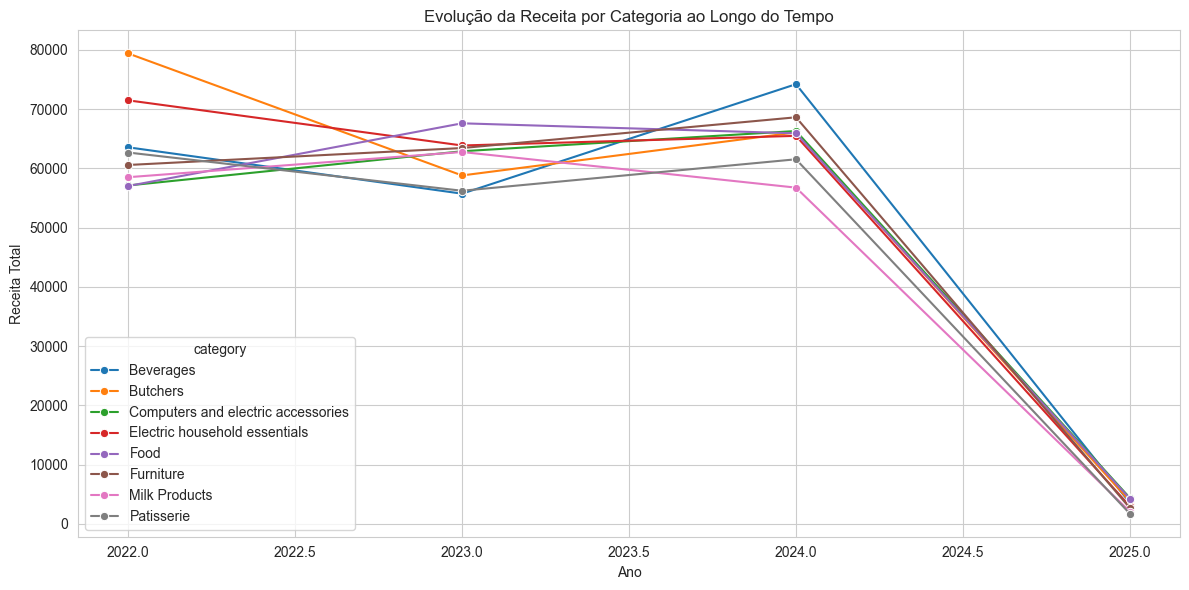

In [196]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=categoria_tempo,
    x='year',
    y='total_revenue',
    hue='category',
    marker='o'
)

plt.title('Evolução da Receita por Categoria ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Receita Total')
plt.tight_layout()
plt.show()

## 📈 Evolução da Receita por Categoria ao Longo do Tempo

Observa-se que a maioria das categorias apresenta crescimento entre 2022 e 2024, indicando expansão consistente do negócio ao longo desse período.

Em 2024, várias categorias atingem seus maiores níveis de receita, com destaque para **Beverages** e **Furniture**, sugerindo fortalecimento da demanda nesses segmentos.

No entanto, o ano de 2025 apresenta uma queda abrupta em todas as categorias.

Esse comportamento indica que os dados de 2025 provavelmente estão incompletos ou representam um período parcial, não sendo comparáveis diretamente com os anos anteriores.

Como consequência:
- As análises estratégicas devem priorizar o período de 2022 a 2024  
- O crescimento observado indica um cenário positivo para o negócio  
- A queda em 2025 não deve ser interpretada como tendência real sem validação adicional  

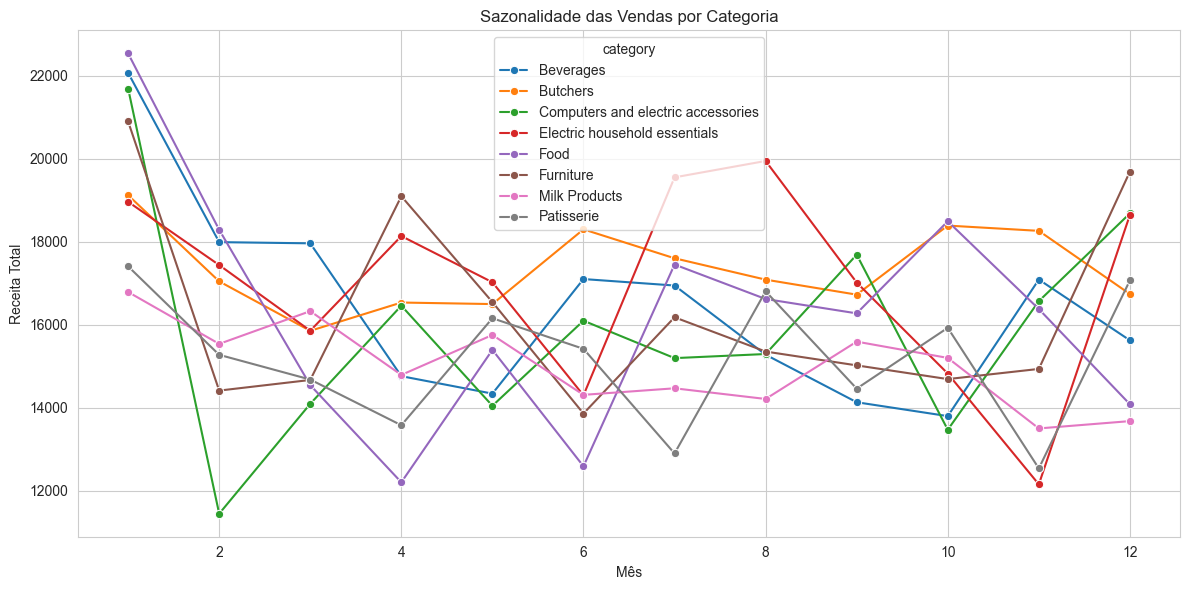

In [197]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=sazonal_categoria,
    x='month',
    y='total_revenue',
    hue='category',
    marker='o'
)

plt.title('Sazonalidade das Vendas por Categoria')
plt.xlabel('Mês')
plt.ylabel('Receita Total')
plt.tight_layout()
plt.show()

## 📅 Sazonalidade das Vendas por Categoria

Observa-se que diferentes categorias apresentam padrões sazonais distintos ao longo dos meses.

Algumas categorias, como **Food** e **Beverages**, apresentam picos mais acentuados em determinados períodos, enquanto outras mantêm comportamento mais estável.

O mês 1 tende a apresentar valores elevados em diversas categorias, sugerindo um padrão comum de aumento no início do ano.

Por outro lado, há variações significativas entre categorias ao longo dos meses, indicando que a sazonalidade não é uniforme.

Como consequência:
- Estratégias comerciais devem ser adaptadas por categoria  
- Planejamento de estoque deve considerar padrões específicos de cada segmento  
- Campanhas promocionais podem ser otimizadas com base nesses ciclos  

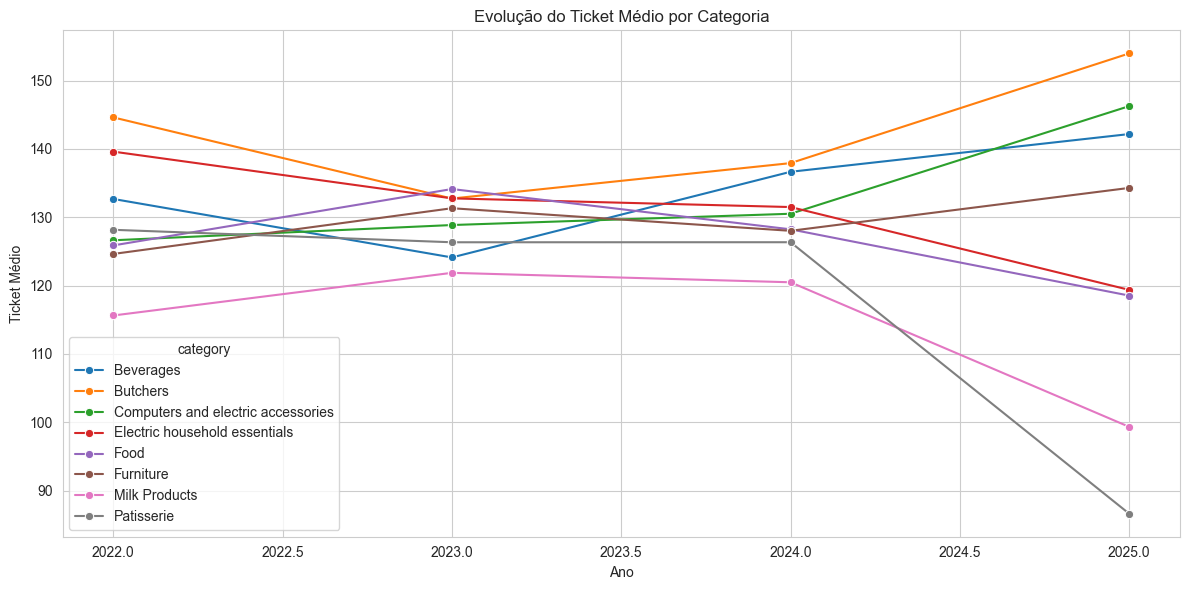

In [198]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ticket_categoria_tempo,
    x='year',
    y='avg_ticket',
    hue='category',
    marker='o'
)

plt.title('Evolução do Ticket Médio por Categoria')
plt.xlabel('Ano')
plt.ylabel('Ticket Médio')
plt.tight_layout()
plt.show()

## 💰 Evolução do Ticket Médio por Categoria

Observa-se que o ticket médio apresenta comportamento relativamente estável entre 2022 e 2024 para a maioria das categorias, indicando consistência no valor das transações.

No entanto, o ano de 2025 apresenta maior volatilidade, com variações significativas entre categorias.

Destaca-se:
- Crescimento relevante no ticket médio de **Butchers**  
- Aumento consistente em **Computers and electric accessories**  
- Queda acentuada em categorias como **Patisserie** e **Milk Products**

Essas variações podem indicar:
- Mudanças no mix de produtos  
- Alterações no comportamento do consumidor  
- Ou impacto de dados incompletos em 2025  

Como consequência:
- O ticket médio deve ser monitorado como indicador de qualidade da receita  
- Alterações significativas devem ser investigadas para identificar causas estruturais  

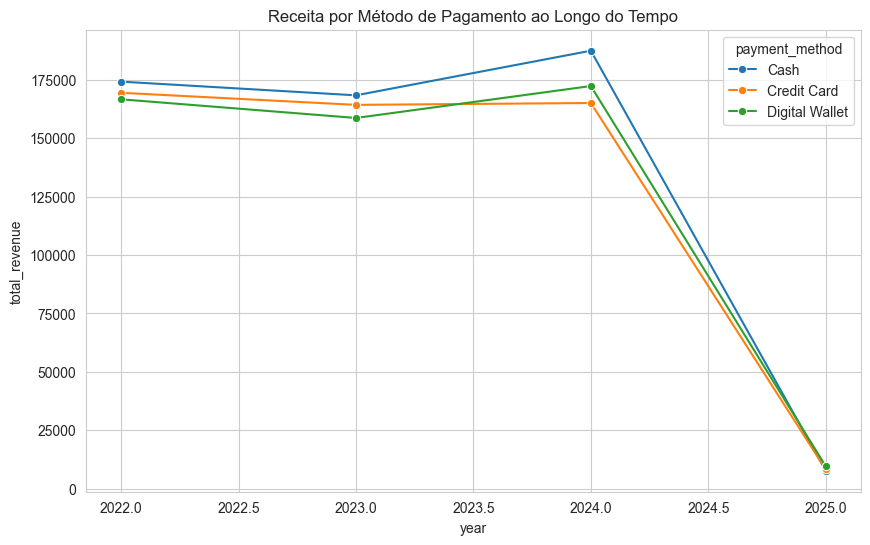

In [199]:
sns.lineplot(
    data=payment_revenue_year,
    x='year',
    y='total_revenue',
    hue='payment_method',
    marker='o'
)

plt.title('Receita por Método de Pagamento ao Longo do Tempo')
plt.show()

## 💳 Receita por Método de Pagamento ao Longo do Tempo

Observa-se que todos os métodos de pagamento apresentam comportamento semelhante ao longo dos anos, com leve crescimento até 2024.

O método **Cash** se mantém como o principal gerador de receita durante todo o período, seguido por **Digital Wallet** e **Credit Card**, que apresentam valores bastante próximos entre si.

Esse padrão indica que não houve mudança significativa na preferência dos clientes ao longo do tempo, com os métodos mantendo participação relativamente estável.

Em 2025, observa-se uma queda abrupta em todos os métodos, indicando dados incompletos ou período parcial, não sendo adequado para análise comparativa.

Como consequência:
- Não há evidência de migração relevante entre métodos de pagamento  
- O comportamento dos clientes permanece consistente ao longo do tempo  
- Estratégias devem focar em otimização da experiência, e não substituição de métodos  

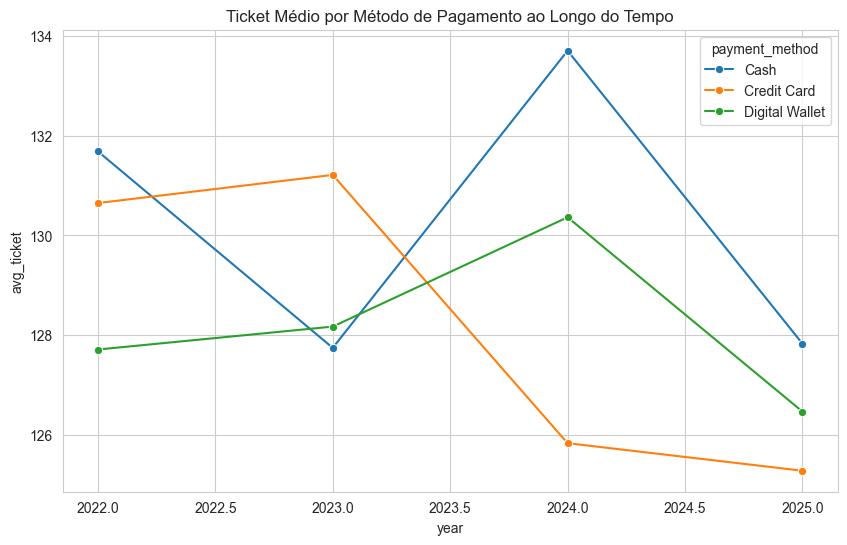

In [200]:
sns.lineplot(
    data=payment_ticket_year,
    x='year',
    y='avg_ticket',
    hue='payment_method',
    marker='o'
)

plt.title('Ticket Médio por Método de Pagamento ao Longo do Tempo')
plt.show()

## 💳 Ticket Médio por Método de Pagamento ao Longo do Tempo

Observa-se que o ticket médio apresenta pequenas variações ao longo dos anos, sem diferenças significativas entre os métodos de pagamento.

O método **Cash** apresenta leve destaque em 2024, com aumento no valor médio das transações, enquanto **Credit Card** apresenta uma leve tendência de queda ao longo do tempo.

O método **Digital Wallet** mantém comportamento relativamente estável, com pequenas oscilações.

De forma geral, não há evidência de que o método de pagamento influencie significativamente o valor das compras.

Como consequência:
- O ticket médio é independente do método de pagamento  
- Estratégias de aumento de valor por transação devem focar em produto e oferta  
- O método de pagamento atua mais como facilitador do que como driver de receita  

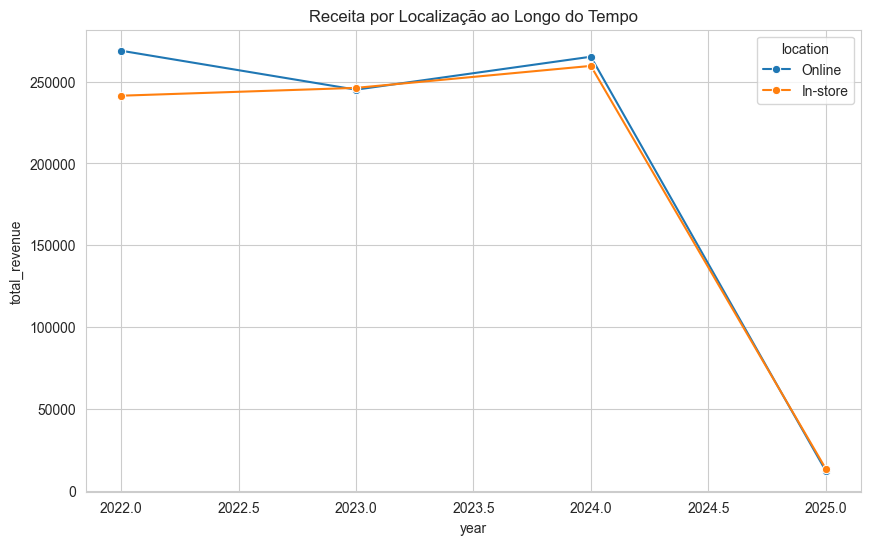

In [201]:
sns.lineplot(
    data=location_revenue_year,
    x='year',
    y='total_revenue',
    hue='location',
    marker='o'
)

plt.title('Receita por Localização ao Longo do Tempo')
plt.show()

## 🌍 Receita por Localização ao Longo do Tempo

Observa-se que os canais **Online** e **In-store** apresentam crescimento até 2024, com comportamento bastante semelhante ao longo do tempo.

O canal **Online** mantém leve vantagem em receita durante a maior parte do período, indicando maior relevância do ambiente digital.

A diferença entre os canais, no entanto, não é extremamente elevada, sugerindo que ambos são importantes para o desempenho do negócio.

Assim como observado anteriormente, 2025 apresenta queda significativa, reforçando a hipótese de dados incompletos.

Como consequência:
- O negócio apresenta estratégia omnichannel bem distribuída  
- O canal online se destaca, mas sem canibalizar o canal físico  
- Ambos os canais devem ser mantidos como pilares do negócio  

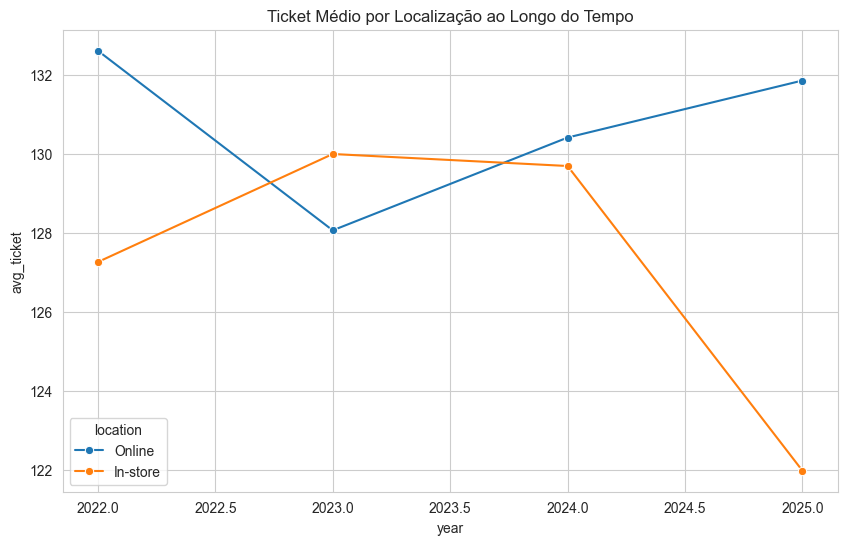

In [202]:
sns.lineplot(
    data=location_ticket_year,
    x='year',
    y='avg_ticket',
    hue='location',
    marker='o'
)

plt.title('Ticket Médio por Localização ao Longo do Tempo')
plt.show()

## 🌍 Ticket Médio por Localização ao Longo do Tempo

Observa-se que o ticket médio do canal **Online** tende a ser superior ao do canal **In-store** na maior parte do período analisado.

Isso indica que compras realizadas no ambiente digital possuem, em média, maior valor por transação.

Além disso, o canal **In-store** apresenta maior volatilidade, com queda mais acentuada em 2025.

Esse comportamento pode indicar diferenças no perfil de consumo entre os canais:
- Online → compras mais planejadas e de maior valor  
- In-store → compras mais frequentes e de menor valor  

Como consequência:
- O canal online pode ser explorado para estratégias de maior valor agregado  
- O canal físico pode focar em conveniência e volume  
- Estratégias diferenciadas por canal podem maximizar resultados  

# 📊 Síntese Final da Análise — Retail Store Sales

## 🎯 Objetivo do Projeto

O objetivo deste projeto foi realizar uma análise exploratória completa de dados de vendas no varejo, com foco em identificar padrões de comportamento, desempenho por categoria e produto, sazonalidade e oportunidades estratégicas para o negócio.

---

## 🧹 Preparação dos Dados

Inicialmente, foi realizado um processo de limpeza e tratamento dos dados, incluindo:

- Imputação de valores ausentes com base em relações matemáticas entre variáveis  
- Reconstrução de informações faltantes (como item) utilizando padrões consistentes no dataset  
- Remoção de registros incompletos após tentativa de recuperação  

Ao final, foram mantidas **11.971 linhas de um total de 12.575**, representando uma perda de apenas **4,80%**, considerada baixa e aceitável.

Esse processo garantiu uma base consistente e confiável para análise.

---

## 📈 Principais Análises Realizadas

### 1. Evolução das Vendas

Foi identificado um crescimento consistente das vendas entre 2022 e 2024, indicando expansão do negócio.

O ano de 2025 apresentou queda significativa, sugerindo dados incompletos e não sendo adequado para comparação direta.

---

### 2. Sazonalidade

Observou-se um padrão sazonal nas vendas:

- Pico no início do ano (mês 1)  
- Recuperação no final do ano (mês 12)  
- Períodos de menor desempenho ao longo do ano  

Esse comportamento indica oportunidades para planejamento estratégico de campanhas e estoque.

---

### 3. Análise por Produto

A distribuição de receita entre os produtos mostra um portfólio diversificado, sem dependência extrema de um único item.

A análise de volume vs preço revelou diferentes perfis de produto:

- Produtos de alto volume  
- Produtos de alto valor agregado  
- Produtos intermediários  

---

### 4. Receita por Categoria

A categoria **Butchers** se destaca como principal geradora de receita, seguida por **Electric household essentials** e **Beverages**.

A distribuição entre categorias é relativamente equilibrada, indicando um portfólio saudável e diversificado.

---

### 5. Ticket Médio

O ticket médio apresentou estabilidade entre 2022 e 2024, sugerindo consistência no comportamento de compra.

No entanto, 2025 apresentou maior volatilidade, reforçando a hipótese de dados incompletos.

---

## 🔀 Análises Cruzadas (Diferencial do Projeto)

### 📊 Ticket Médio + Receita por Categoria

A categoria **Butchers** combina:

- Alto ticket médio  
- Alta receita  

Indicando forte relevância estratégica.

Categorias como **Milk Products** apresentam:

- Baixo ticket médio  
- Baixa receita  

Sugerindo menor impacto no negócio.

---

### 📦 Volume vs Valor (Produtos)

A análise mostrou que:

- Não há correlação direta entre preço e volume  
- O portfólio atende diferentes perfis de consumo  

Isso reforça a necessidade de estratégias segmentadas.

---

### 📅 Sazonalidade por Categoria

Foi identificado que diferentes categorias apresentam padrões sazonais distintos, indicando que estratégias generalistas podem não ser eficientes.

---

### 💳 Métodos de Pagamento

As análises indicam que os métodos de pagamento apresentam comportamento estável ao longo do tempo, sem mudanças significativas na preferência dos clientes.

O método **Cash** mantém leve liderança em receita, mas sem grande disparidade em relação aos demais.

Além disso, o ticket médio é praticamente uniforme entre os métodos, indicando que a forma de pagamento **não influencia o valor das compras**.

---

### 🌍 Localização (Online vs In-store)

O canal **Online** apresenta maior geração de receita ao longo do tempo, além de leve vantagem em ticket médio.

Esse comportamento indica que:

- O crescimento do negócio é impulsionado principalmente pelo canal digital  
- O ticket médio mais elevado no online sugere compras mais planejadas ou de maior valor  

Por outro lado, o canal físico mantém relevância, com comportamento consistente, reforçando uma estratégia omnichannel equilibrada.

---

## 💡 Principais Insights

- O negócio apresenta crescimento consistente até 2024  
- Existe sazonalidade relevante nas vendas  
- O portfólio é diversificado, com múltiplos drivers de receita  
- A categoria Butchers é o principal pilar do negócio  
- O ticket médio é estável, indicando consistência no comportamento do consumidor  
- Diferentes categorias e produtos exigem abordagens estratégicas distintas  
- O método de pagamento não impacta significativamente o valor das compras  
- O canal online se destaca como principal motor de crescimento, impulsionado por maior volume e leve aumento no ticket médio  

---

## 🚀 Recomendações Estratégicas

Com base na análise, recomenda-se:

### 📈 Maximização de Receita
- Priorizar categorias com alto ticket e alta receita (ex: Butchers)

### 📦 Gestão de Portfólio
- Reavaliar produtos e categorias de baixo desempenho  
- Investir em produtos de alto valor agregado  

### 📅 Planejamento Sazonal
- Intensificar campanhas em períodos de alta demanda  
- Criar ações específicas para períodos de baixa  

### 💳 Experiência de Pagamento
- Manter diversidade de métodos, garantindo conveniência ao cliente  
- Focar na experiência e não na priorização de um método específico  

### 🌍 Estratégia de Canal
- Priorizar o canal online como principal driver de crescimento  
- Investir em experiência digital e aquisição de clientes  
- Manter o canal físico como suporte estratégico para volume e presença de marca  

### 🎯 Estratégia Comercial
- Aplicar estratégias segmentadas por categoria e canal  
- Explorar oportunidades de upsell e cross-sell  

---

## 🧠 Conclusão

A análise revelou um negócio em crescimento, com base sólida e comportamento de vendas consistente ao longo do tempo.

O desempenho observado é impulsionado principalmente por aumento de volume e expansão do canal digital, e não por mudanças estruturais no comportamento de compra.

A combinação de análise temporal, segmentação por categoria, comportamento de pagamento e localização permitiu uma visão abrangente do negócio, gerando insights acionáveis e alinhados com decisões estratégicas.

O projeto demonstra a capacidade de transformar dados em informação relevante para o negócio, indo além da análise descritiva e contribuindo para a tomada de decisão orientada por dados.